测试数据和训练数据分组，数据分batch

In [ ]:
# Part 1: 模型训练
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data as data_utils
from torch.utils.data import DataLoader, TensorDataset
from joblib import load, dump
import matplotlib.pyplot as plt

# -----------------------------
# 1. 数据加载与预处理
# -----------------------------

def prepare_dataloader(df, batch_size=32):
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)  # 强制转换为整数类型
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (batch_size, 1, 1024)
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

# 加载数据集
train_set = load('train_set')
val_set = load('val_set')

train_loader = prepare_dataloader(train_set)
val_loader = prepare_dataloader(val_set)

# -----------------------------
# 2. 模型定义
# -----------------------------

class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        x = self.cnn(x)  # (batch_size, 64, 511)
        x = x.permute(0, 2, 1)  # (batch_size, 511, 64)
        x, _ = self.lstm(x)  # (batch_size, 511, 128)
        x = x[:, -1, :]  # (batch_size, 128)
        return self.classifier(x)

# -----------------------------
# 3. 模型初始化与训练配置
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

# -----------------------------
# 4. 训练循环
# -----------------------------

num_epochs = 100
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    # 验证阶段
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_losses[-1]:.4f}, Accuracy: {train_accs[-1]:.4f}, "
          f"Val Loss: {val_losses[-1]:.4f}, Accuracy: {val_accs[-1]:.4f}")

# -----------------------------
# 5. 保存模型和训练指标
# -----------------------------

torch.save(model.state_dict(), 'cnn_lstm_bearing.pth')
dump(train_losses, './matfiles/train_loss')
dump(train_accs, './matfiles/train_acc')
dump(val_losses, './matfiles/validate_loss')
dump(val_accs, './matfiles/validate_acc')

Epoch [1/100], Train Loss: 2.2926, Accuracy: 0.1300, Val Loss: 2.2146, Accuracy: 0.1674
Epoch [2/100], Train Loss: 2.0331, Accuracy: 0.1864, Val Loss: 1.8312, Accuracy: 0.2146
Epoch [3/100], Train Loss: 2.3156, Accuracy: 0.1429, Val Loss: 2.3720, Accuracy: 0.0880
Epoch [4/100], Train Loss: 2.3065, Accuracy: 0.1269, Val Loss: 2.2944, Accuracy: 0.1545
Epoch [5/100], Train Loss: 2.2949, Accuracy: 0.1153, Val Loss: 2.2953, Accuracy: 0.1760
Epoch [6/100], Train Loss: 2.2441, Accuracy: 0.1864, Val Loss: 2.3898, Accuracy: 0.0858
Epoch [7/100], Train Loss: 2.3168, Accuracy: 0.0999, Val Loss: 2.3117, Accuracy: 0.0858
Epoch [8/100], Train Loss: 2.3015, Accuracy: 0.0987, Val Loss: 2.3009, Accuracy: 0.1073
Epoch [9/100], Train Loss: 2.2383, Accuracy: 0.1833, Val Loss: 2.1289, Accuracy: 0.1888
Epoch [10/100], Train Loss: 2.1082, Accuracy: 0.1956, Val Loss: 2.0322, Accuracy: 0.1931
Epoch [11/100], Train Loss: 2.1319, Accuracy: 0.1686, Val Loss: 2.0309, Accuracy: 0.1974
Epoch [12/100], Train Loss: 1.

KeyboardInterrupt: 


Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0     0.7667    1.0000    0.8679        23
     Class 1     0.4255    0.9091    0.5797        22
     Class 2     0.4000    0.3200    0.3556        25
     Class 3     0.0000    0.0000    0.0000        27
     Class 4     1.0000    1.0000    1.0000        18
     Class 5     0.7619    0.7619    0.7619        21
     Class 6     0.8750    0.7778    0.8235        27
     Class 7     1.0000    1.0000    1.0000        22
     Class 8     0.6538    0.6538    0.6538        26
     Class 9     0.7600    0.8636    0.8085        22

    accuracy                         0.7039       233
   macro avg     0.6643    0.7286    0.6851       233
weighted avg     0.6452    0.7039    0.6636       233



d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


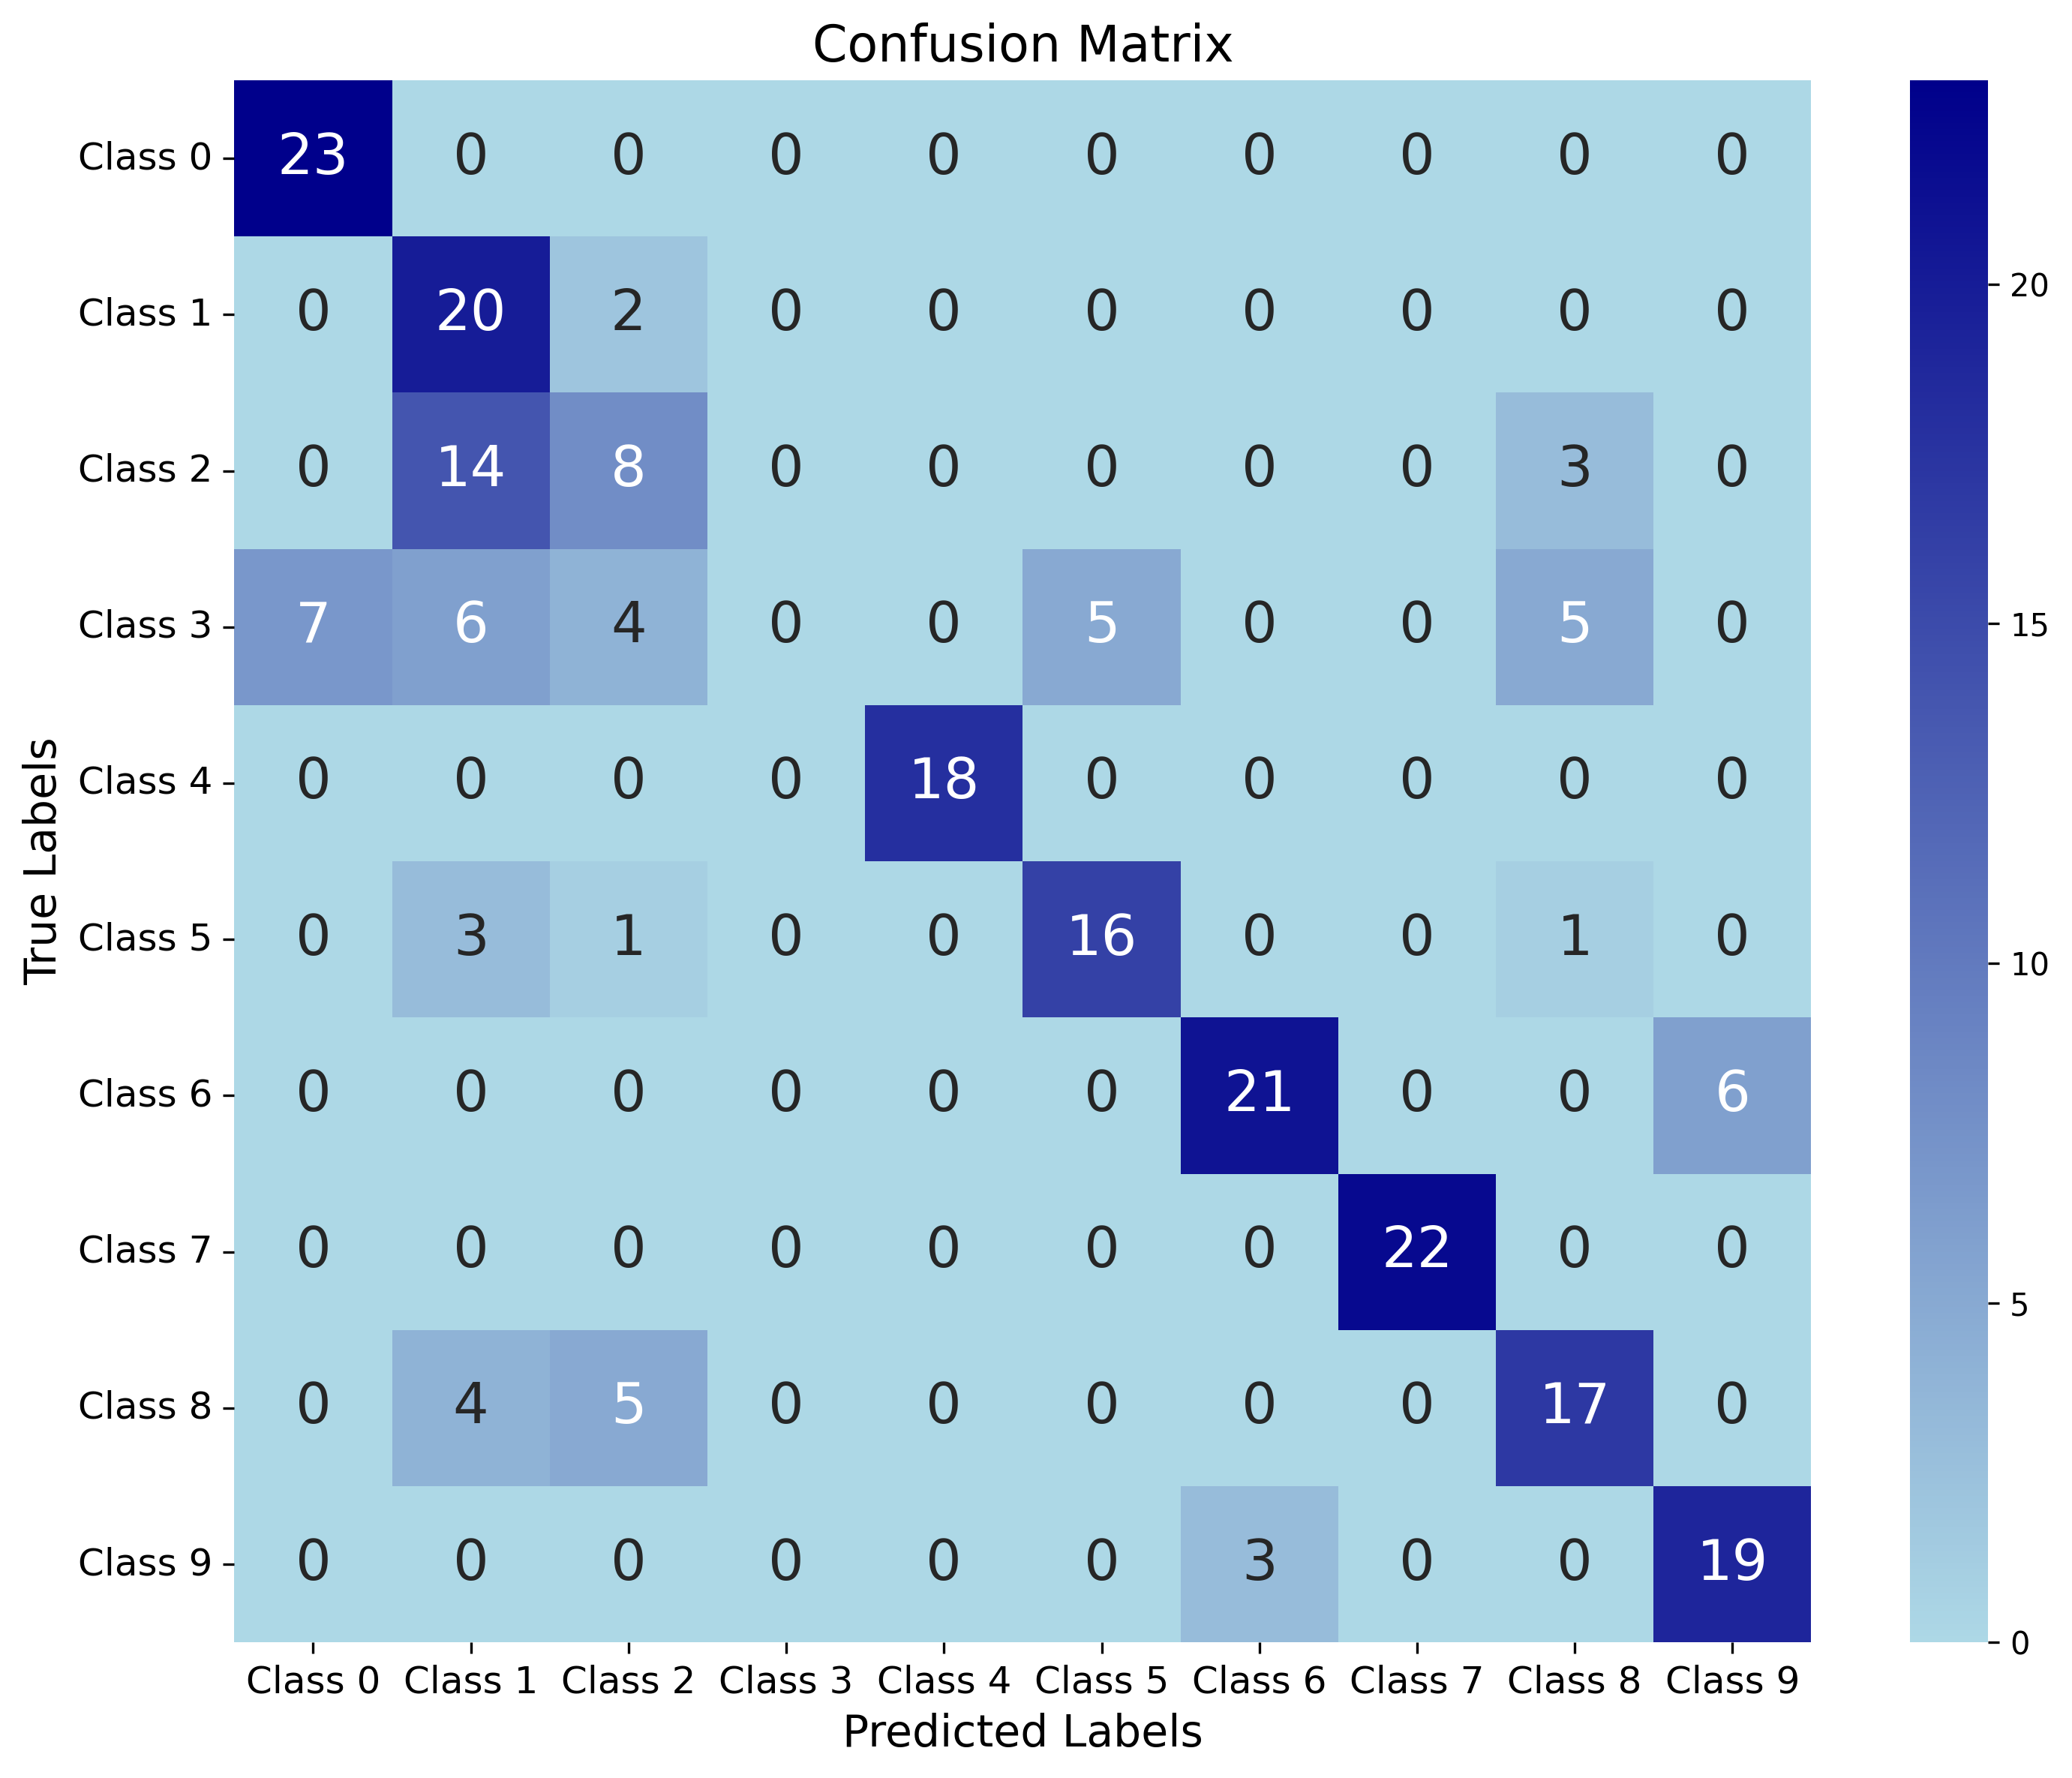


Class      Precision  Recall     F1-Score   Support   
Class 0    0.7667     1.0000     0.8679     23        
Class 1    0.4255     0.9091     0.5797     22        
Class 2    0.4000     0.3200     0.3556     25        
Class 3    0.0000     0.0000     0.0000     27        
Class 4    1.0000     1.0000     1.0000     18        
Class 5    0.7619     0.7619     0.7619     21        
Class 6    0.8750     0.7778     0.8235     27        
Class 7    1.0000     1.0000     1.0000     22        
Class 8    0.6538     0.6538     0.6538     26        
Class 9    0.7600     0.8636     0.8085     22        

Metric       Precision  Recall     F1-Score   Support   
accuracy                           0.7039     233.0     
macro avg    0.6643     0.7286     0.6851     233       
weighted avg 0.6452     0.7039     0.6636     233       


d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Part 2: 模型评估
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data as data_utils
from torch.utils.data import DataLoader, TensorDataset
from joblib import load
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# 1. 数据加载与预处理
# -----------------------------

def prepare_dataloader(df, batch_size=32):
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)  # 强制转换为整数类型
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (batch_size, 1, 1024)
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return loader

# 加载测试集
test_set = load('test_set')
test_loader = prepare_dataloader(test_set)

# -----------------------------
# 2. 模型定义（必须与训练时一致）
# -----------------------------

class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        x = self.cnn(x)  # (batch_size, 64, 511)
        x = x.permute(0, 2, 1)  # (batch_size, 511, 64)
        x, _ = self.lstm(x)  # (batch_size, 511, 128)
        x = x[:, -1, :]  # (batch_size, 128)
        return self.classifier(x)

# -----------------------------
# 3. 加载模型
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM().to(device)
model.load_state_dict(torch.load('cnn_lstm_bearing.pth'))
model.eval()

# -----------------------------
# 4. 收集预测结果
# -----------------------------

def collect_predictions(model, test_loader, device):
    model.eval()
    model.to(device)
    y_true = []
    y_pred = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = collect_predictions(model, test_loader, device)

# -----------------------------
# 5. 分类报告与混淆矩阵
# -----------------------------

target_names = [f"Class {i}" for i in range(10)]
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

confusion_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8), dpi=300)
cmap = LinearSegmentedColormap.from_list("custom_blues", ["#ADD8E6", "#00008B"])
sns.heatmap(
    confusion_mat,
    xticklabels=target_names,
    yticklabels=target_names,
    annot=True,
    annot_kws={'size': 18},
    fmt='d',
    cmap=cmap
)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# -----------------------------
# 6. 扩展指标输出（精确率、召回率、F1分数）
# -----------------------------

report = classification_report(y_true, y_pred, output_dict=True, target_names=target_names)

print("\n{:<10} {:<10} {:<10} {:<10} {:<10}".format('Class', 'Precision', 'Recall', 'F1-Score', 'Support'))
for i in range(10):
    class_name = f"Class {i}"
    metrics = report[class_name]
    print("{:<10} {:<10.4f} {:<10.4f} {:<10.4f} {:<10}".format(
        class_name,
        metrics['precision'],
        metrics['recall'],
        metrics['f1-score'],
        int(metrics['support'])
    ))

print("\n{:<12} {:<10} {:<10} {:<10} {:<10}".format('Metric', 'Precision', 'Recall', 'F1-Score', 'Support'))
for metric in ['accuracy', 'macro avg', 'weighted avg']:
    if metric == 'accuracy':
        print("{:<12} {:<10} {:<10} {:<10.4f} {:<10}".format(
            metric,
            "",
            "",
            report[metric],
            sum([v['support'] for k, v in report.items() if k not in ['accuracy', 'macro avg', 'weighted avg']])
        ))
    else:
        print("{:<12} {:<10.4f} {:<10.4f} {:<10.4f} {:<10}".format(
            metric,
            report[metric]['precision'],
            report[metric]['recall'],
            report[metric]['f1-score'],
            int(report[metric]['support'])
        ))

注意调整参数，
1. 可以适当增加 GCN层数 和每层神经元个数，微调学习率；
2. 增加更多的 epochs,  （注意防止过拟合）